In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv("../data/clinical_clean.csv")

df['event'] = (df['demographic.vital_status'] == 'Dead').astype(int)

def stage_group(stage):
    if pd.isna(stage):
        return np.nan
    if stage.startswith('Stage I') and not any(stage.startswith(s) for s in ['Stage II', 'Stage III', 'Stage IV']):
        return 'Early (I-II)'
    elif stage.startswith('Stage II') and not stage.startswith('Stage III'):
        return 'Early (I-II)'
    elif stage.startswith('Stage III') or stage.startswith('Stage IV'):
        return 'Advanced (III-IV)'
    else:
        return np.nan

df['stage_group'] = df['diagnoses.ajcc_pathologic_stage'].apply(stage_group)

print("Shape:", df.shape)
df.head()

Shape: (1036, 13)


,cases.case_id,demographic.gender,demographic.age_at_index,demographic.vital_status,demographic.days_to_death,diagnoses.days_to_last_follow_up,diagnoses.ajcc_pathologic_stage,diagnoses.primary_diagnosis,demographic.race,demographic.ethnicity,days_to_event,event,stage_group
0,001cef41-ff86-4d3f-a140-a647ac4b10a1,female,60.0,Alive,NaN,337.0,Stage IA,"Infiltrating duct carcinoma, NOS",white,not hispanic or latino,337.0,0,Early (I-II)
1,0045349c-69d9-4306-a403-c9c1fa836644,female,70.0,Alive,NaN,259.0,Stage I,Adenoid cystic carcinoma,white,not hispanic or latino,259.0,0,Early (I-II)
2,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,female,50.0,Alive,NaN,3102.0,Stage IIB,Apocrine adenocarcinoma,white,not hispanic or latino,3102.0,0,Early (I-II)
3,00a2d166-78c9-4687-a195-3d6315c27574,female,56.0,Alive,NaN,5.0,Stage IIA,"Infiltrating duct carcinoma, NOS",white,not hispanic or latino,5.0,0,Early (I-II)
4,01263518-5f7c-49dc-8d7e-84b0c03a6a63,female,76.0,Alive,NaN,304.0,Stage IV,"Infiltrating duct carcinoma, NOS",not reported,not reported,304.0,0,Advanced (III-IV)


In [2]:
early = df[df['stage_group'] == 'Early (I-II)']
advanced = df[df['stage_group'] == 'Advanced (III-IV)']

results = logrank_test(
    early['days_to_event'], advanced['days_to_event'],
    event_observed_A=early['event'], event_observed_B=advanced['event']
)

print(f"Test statistic: {results.test_statistic:.2f}")
print(f"P-value: {results.p_value:.2e}")

if results.p_value < 0.05:
    print("\nThe difference is  statistically significant (p < 0.05)")
else:
    print("\nThe difference is not statistically significant (p >= 0.05)")

Test statistic: 21.51
P-value: 3.53e-06

The difference is  statistically significant (p < 0.05)


## Statistical Validation: Log-Rank Test

To confirm that the survival difference observed between early-stage and advanced-stage patients is statistically meaningful (and not due to chance), a log-rank test was performed comparing the two Kaplan-Meier curves.

**Result**: test statistic = 21.51, p-value = 3.53e-06

The p-value is far below the conventional significance threshold (0.05), confirming that the survival difference between early-stage (I-II) and advanced-stage (III-IV) patients is statistically significant. This provides formal statistical support for the visual separation observed in the Kaplan-Meier plot from the previous notebook.

In [3]:
df_cox = df[['days_to_event', 'event', 'demographic.age_at_index', 'stage_group']].dropna()

df_cox['advanced_stage'] = (df_cox['stage_group'] == 'Advanced (III-IV)').astype(int)
df_cox = df_cox.drop(columns=['stage_group'])

df_cox = df_cox.rename(columns={'demographic.age_at_index': 'age'})

print("Dataset for Cox:", df_cox.shape)
df_cox.head()

Dataset for Cox: (977, 4)


,days_to_event,event,age,advanced_stage
0,337.0,0,60.0,0
1,259.0,0,70.0,0
2,3102.0,0,50.0,0
3,5.0,0,56.0,0
4,304.0,0,76.0,1


In [4]:
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='days_to_event', event_col='event')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 977 total observations, 873 right-censored observations>
             duration col = 'days_to_event'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 977
number of events observed = 104
   partial log-likelihood = -560.48
         time fit was run = 2026-06-21 20:40:07 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
age             0.04      1.04      0.01            0.03            0.06                1.03                1.06
advanced_stage  0.97      2.65      0.20            0.58            1.37                1.78                3.94

                cmp to    z      p  -log2(p)
covariate                                   
age               0.00 5.38 <0.005     23.68
advanced_stage    0.00 4.82 <0.005     19.38
---
Concordance = 0.74
Partial AIC = 1124.95
log-likelihood ratio test = 47.89 on 2 df
-log2(p) of ll-ratio test = 34.55

## Cox Proportional Hazards Model

To quantify the individual contribution of age and cancer stage to mortality risk while controlling for both factors simultaneously, a Cox Proportional Hazards model was fitted.

**Key results:**
- **Age**: HR = 1.04 (p < 0.005) each additional year of age is associated with a 4% increase in risk of death.
- **Advanced stage**: HR = 2.65 (p < 0.005) patients diagnosed at an advanced stage (III-IV) have a 2.65-fold higher risk of death compared to early-stage patients, after adjusting for age.
- **Concordance index**: 0.74, indicating good discriminative ability of the model.

These results confirm that stage at diagnosis is a substantially stronger predictor of mortality risk than age in this cohort, reinforcing the clinical value of early detection.

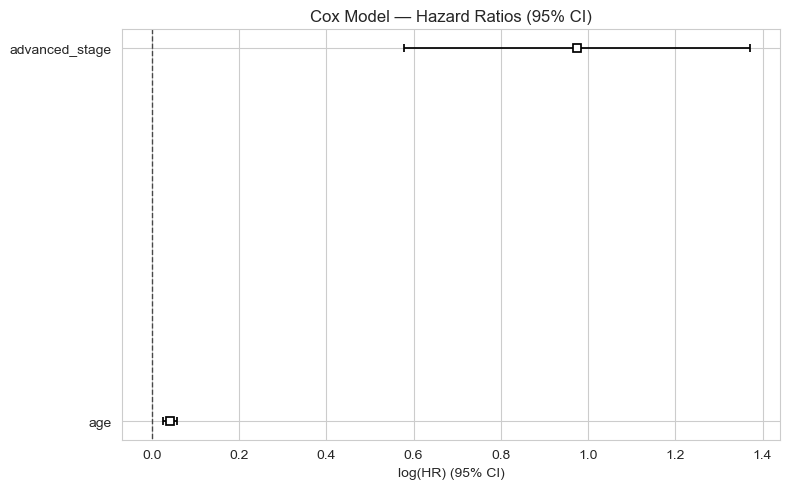

In [6]:
plt.figure(figsize=(8, 5))
cph.plot()
plt.title('Cox Model — Hazard Ratios (95% CI)')
plt.tight_layout()
plt.savefig('../results/plots/cox_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## Forest Plot — Cox Model Hazard Ratios

This forest plot visualizes the log hazard ratios from the Cox model, with 95% confidence intervals. Neither confidence interval crosses zero, confirming that both age and advanced stage are statistically significant predictors of mortality risk. The much larger effect size for advanced stage compared to age is clearly visible, reinforcing stage at diagnosis as the dominant prognostic factor in this cohort.

## Summary of Survival Insights

- The survival difference between early-stage (I-II) and advanced-stage (III-IV) patients is statistically significant (log-rank test, p = 3.53e-06).
- A Cox Proportional Hazards model confirmed that advanced stage is associated with a 2.65-fold increase in mortality risk (p < 0.005), independent of age.
- Age also contributes significantly to risk (4% increase per year, p < 0.005), but its effect is substantially smaller than stage.
- The model achieves a concordance index of 0.74, indicating good discriminative performance despite using only two predictors.

These findings reinforce stage at diagnosis as the primary clinical driver of survival outcomes in this cohort, with age playing a secondary but still significant role.